In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce
from matplotlib.patches import Patch

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.api as sm

sys.path.append("scripts")
from utils import *

# load all utils functions
os.chdir("../../")

data_utils_dir = "./data_processing/data_utils"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results" # change
MIC_data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs" # change

data_dir = "./analysis/TRUST/processed_data"

model_loci = pd.read_csv(f"{data_utils_dir}/drug_loci.csv")

# for survival analysis
import lifelines
from epi_utils import *
from datetime import datetime

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

who_variants = pd.read_csv(f"{data_utils_dir}/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

TRUST_TRUST_isolate_variants = pd.read_csv(f"{data_dir}/isolate_variants_WHO_catalog.csv")

cc_df = pd.read_csv(f"{data_utils_dir}/drug_CC.csv")

MGIT_cc_dict = {'RIF': 0.5, 'EMB': 5, 'INH': 0.1, 'PZA': 100}

# MIC encoding from the TRUST codebook
MIC_encoding_dicts = {'RIF': {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,inf'},
                      'INH': {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,inf'},
                      'EMB': {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,inf'},
                      'PZA': {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,inf'}
                     }

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

MIC_label_encoding_dicts = {'RIF': RIF_label_encoding_dict, 'INH': INH_label_encoding_dict, 'EMB': EMB_label_encoding_dict, 'PZA': PZA_label_encoding_dict}

final_keep_pids = pd.read_csv(f"{data_dir}/final_keep_pids.txt", sep='\t', header=None)[0].values
imputation_dir = "./analysis/TRUST/imputation"

# Read in all patient data -- RedCap, predicted MICs, and measured MICs transformed to µg/mL in MGIT

In [2]:
df_TTP_smear = pd.read_csv(os.path.join(data_dir, "TTP_smear_results.csv"))
df_TCC = pd.read_csv(os.path.join(data_dir, "TCC.csv"))
df_cultures = pd.read_csv(os.path.join(data_dir, "cultures.csv"))

print(f"{df_TCC.pid.nunique()} pids for the TCC analysis")
print(f"{df_TTP_smear.dropna(subset='culture_sample_num').query('culture_sample_num <= 2').pid.nunique()} pids with baseline TTPs within the first 2 weeks")

388 pids for the TCC analysis
403 pids with baseline TTPs within the first 2 weeks


In [3]:
df_trust_patients, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(os.path.join(data_dir, "cleaned_patient_data_for_analysis.csv"), 
                                                                                {'RIF': 'lineage_amino_acid', 
                                                                                 'INH': 'lineage_amino_acid', 
                                                                                 'EMB': 'lineage_amino_acid', 
                                                                                 'PZA': 'amino_acid'}, # dictionary for which model to get predictions for
                                                                                CNN_results_dir=results_dir,
                                                                                baseline_only=True
                                                                               )

# there are 2 patients without smear, who get dropped later. Do it now so that the overview figures match
# df_trust_patients = df_trust_patients.dropna(subset=['total_adherence', 'adherence_12week', 'smear_pos_no_contam_sputum_specimen_1']).reset_index(drop=True)
df_trust_patients = df_trust_patients.dropna(subset=['smear_pos_no_contam_sputum_specimen_1']).reset_index(drop=True)

# there's only 1 L1 patient, so remove them
# assert len(df_trust_patients.query("Lineage=='1'")) == 1
# df_trust_patients = df_trust_patients.query("Lineage!='1'")

df_pred_combined['inh_resistant'] = (df_pred_combined['INH_pred_MIC'] >= 0.1).astype(int)
TRUST_phenos['inh_resistant'] = (TRUST_phenos['INH_lower_bound'] >= 0.1).astype(int)

# see how many patients have a valid TCC (not too much missingness basically. Can't impute too many cultures)
num_pids_with_metadata = df_trust_patients.pid.nunique()
df_trust_patients = df_trust_patients.merge(df_TCC, on='pid')

# keep the first enrolled instance of each patient
num_pids_with_valid_TCC = df_trust_patients.pid.nunique()
df_trust_patients = df_trust_patients.sort_values(['unique_patient', 'pid', 'Sampling_Week']).drop_duplicates(['unique_patient'], keep='first')

print(f"{num_pids_with_valid_TCC}/{num_pids_with_metadata} patients with valid TCC, WGS, and MICs")
print(f"{df_trust_patients.pid.nunique()}/{num_pids_with_valid_TCC} unique patients (no reenrollments) with valid TCC, WGS, and MICs")

404 patients with any WGS samples
404 patients with uncontaminated WGS samples
394 patients with uncontaminated WGS samples taken in the first 2 weeks

1 patients: ['T0402'] have multiple sequences at the same timepoint
Removing 1 patients: ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
394 patients have MICs for RIF
394 patients have MICs for INH
394 patients have MICs for EMB
275 patients have MICs for PZA
391 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 393 pids
Found predicted INH MICs for 393 pids
Found predicted EMB MICs for 393 pids
Found predicted PZA MICs for 393 pids
393 patients have predicted MICs
361/391 patients with valid TCC, WGS, and MICs
361/361 unique patients (no reenrollments) with valid TCC, WGS, and MICs


In [4]:
# just to get the counts
df_trust_patients = add_household_numbers(df_trust_patients)
df_trust_patients.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

59 patients share a household with another patient, accounting for 31 households
333 unique households across 361 patients


array([3, 2, 1, 4])

In [5]:
df_trust_patients.Lineage.unique()

array(['2', '3', '4', '1', '2,4'], dtype=object)

# 1. Generate Helper Files for Culture Imputation

## 1a. Imputation file generated from the TRUST RedCap data that Sarah Thomson sent. Need to adjust a few columns (types, dates)

### 1b. Sputum and smear data -- extract from TRUST RedCap

In [6]:
def process_sputum_smear_data_for_imputation(df_TCC, df_cultures):
    '''
    Exclude TTP from the imputation because only positive uncontaminated samples have a TTP
    '''

    # keep only samples up to 12. Beyond that, those aren't actually weekly samples. Don't remove pids who are not valid for the TCC analysis
    # because they are valid for the poor outcome / relapse models
    df_smear_cultures = df_cultures.query("sample_num <= 12")

    # next, make the replacements:
    df_smear_cultures['result'] = df_smear_cultures['result'].replace('tb_positive_contaminated', 'tb_positive').replace('tb_negative_contaminated', np.nan)
    print(df_smear_cultures.result.unique())

    df_cultures = df_smear_cultures[['pid', 'sample_num', 'result']].rename(columns={'result': 'culture'})
    df_smear = df_smear_cultures[['pid', 'sample_num', 'smear_grade']]

    # pivot to matrix. Remove patients who are not valid from the TCC analysis from the sputum cultures matrix
    df_cultures = df_cultures.query("pid in @df_TCC.pid").pivot(index='pid', columns = 'sample_num', values = 'culture')
    df_smear = df_smear.pivot(index='pid', columns = 'sample_num', values = 'smear_grade')

    df_cultures.columns = [f"culture_{num}" for num in df_cultures.columns]
    df_smear.columns = [f"smear_grade_{num}" for num in df_smear.columns]

    return df_cultures, df_smear

In [7]:
cultures_matrix, smear_grade_matrix = process_sputum_smear_data_for_imputation(df_TCC.query("pid in @df_trust_patients.pid"), df_cultures.query("pid in @df_trust_patients.pid"))

smear_positivity_matrix = np.where(smear_grade_matrix > 0, 1, np.where(smear_grade_matrix == 0, 0, np.nan))
smear_positivity_matrix = pd.DataFrame(smear_positivity_matrix, index=smear_grade_matrix.index, columns=smear_grade_matrix.columns.str.replace('grade', 'positivity'))

print(f"{len(cultures_matrix)} patients for the TCC analysis")
print(f"{len(smear_grade_matrix)} patients in the smear dataframe")

cultures_matrix.to_csv(f"{imputation_dir}/cultures.csv")
smear_grade_matrix.to_csv(f"{imputation_dir}/smear_grade.csv")
smear_positivity_matrix.to_csv(f"{imputation_dir}/smear_positivity.csv")

['tb_positive' 'tb_negative' nan]
361 patients for the TCC analysis
361 patients in the smear dataframe


In [8]:
# add INH resistant
df_for_imputation = df_trust_patients.merge(TRUST_phenos[['pid', 'inh_resistant']], how='left')

# for pids without measured MICs, fill in with the predicted MICs. There will be predicted MICs for everyone because df_for_imputation only contains pids with WGS
df_for_imputation['inh_resistant'] = df_for_imputation['inh_resistant'].fillna(df_for_imputation['pid'].map(dict(zip(df_pred_combined['pid'], df_pred_combined['inh_resistant']))))

df_for_imputation['Timika_PLI_difference'] = df_for_imputation['predicted_Timika_Score'] - df_for_imputation['predicted_PLI']

print(df_for_imputation['inh_resistant'].value_counts(dropna=False))

inh_resistant
0.0    338
1.0     23
Name: count, dtype: int64


In [9]:
# these will be used to impute the cultures. They will not be imputed themselves
covariates_for_imputation = [
    "pid",
    "screen_years",
    "screen_sex",
    "bl_bmi",  # need to keep this because it's used in the models to determine underweight binary var
    # "bmi",  # ordinal variable from underweight to normal to obese
    "HIV_CD4",  # categorical variable: 0 = HIV-, 1 = HIV+/high CD4, 2 = HIV+/low CD4
    "fstrom1_baseline",
    "smoked_substance_use",
    "bl_mandrax",
    # "bl_prevtb",
    # "diabetes",
    # "total_adherence",
    # "adherence_12week",
    "inh_resistant",
    # "peth_value_baseline",
    "alcohol_use",  # LCA group: They grouped people by alcohol use
    # "RIF_AUC",
    # "INH_AUC",
    # "EMB_AUC",
    # "PZA_AUC",
    "TTP_baseline",
    # "smear_grade_baseline",
    # "cxr_cavity_chest_radiograph_1"
]

# from Sam's paper:https://pmc.ncbi.nlm.nih.gov/articles/PMC9675206/
# culture result from previous week, smear result from previous week, age, biologic sex, body mass index (BMI), HIV status, tobacco use, smoked drug use, cavitary disease, and excessive alcohol use. 

In [10]:
# these need to be converted to 0/1 because R can not interpret True/False saved from Python
for col in covariates_for_imputation:
    if df_for_imputation[col].dtype == bool:
        df_for_imputation[col] = pd.to_numeric(df_for_imputation[col], errors='coerce').astype(int)

In [11]:
# save
df_for_imputation = df_for_imputation.dropna(subset=covariates_for_imputation)
print(f"{df_for_imputation.pid.nunique()} patients for imputation")

df_for_imputation.sort_values("pid").to_csv(f"{imputation_dir}/patient_data.csv", index=False)

353 patients for imputation


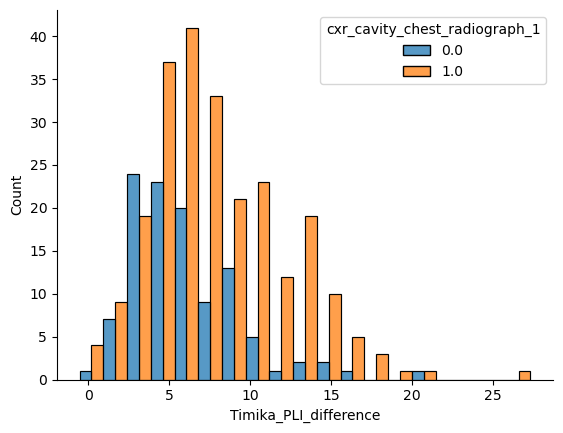

In [13]:
sns.histplot(data=df_for_imputation,
             x='Timika_PLI_difference',
             hue='cxr_cavity_chest_radiograph_1',
             multiple='dodge',
             
            )

sns.despine()
plt.show()

In [14]:
df_for_imputation.groupby('cxr_cavity_chest_radiograph_1')['Timika_PLI_difference'].mean()

cxr_cavity_chest_radiograph_1
0.0    6.014851
1.0    8.022286
Name: Timika_PLI_difference, dtype: float64

# Survival Analysis

When culture_convert = 0, patients are right-censored, meaning that their culture conversion time is unknown because it's after the end of the study

# Variables for TCC Model:

Prefixes:

<ul>
    <li>screen = Screening visit</li>
    <li>bl = Baseline visit</li>
    <li>pk = Pharmacokinetics visit</li>
    <li>fu = Follow up (monthly)</li>
</ul>

<ul>
    <li>bl_years: Age as an integer</li>
    <li>bl_hiv: Binary variable, is the patient HIV+. Wait, bl_hiv is the same thing?</li>
    <li>bl_cd4: CD4 count, integer. </li>
    <li>bl_vl: Viral load result: float or "undetectable"</li>
    <li>bl_art: 1 = yes ART, 0 = no</li>
    <li>screen_sex: Binary, 1 = male, 2 = female</li>
    <li>Drug use (1 = +, 0 = -, 2 = indeterminate):</li>
        <ul>
            <li>bl_cannabis</li>
            <li>bl_meth</li>
            <li>bl_cocaine</li>
            <li>bl_opiates</li>
            <li>bl_amphetamine</li>
            <li>bl_mandrax: Methaqualone (most common I think?)</li>
        </ul>
    <li>bl_afbprog: 3 = +++, 2 = ++, 1 = +, 4 = scanty, 0 = No acid-fast bacillus, 5 = contaminated, 6 = Not done.</li>
    <li>bl_bmi: BMI</li>
    <li>pk_bac: blood alcohol concentration: float from 0-0.99</li>
    <li>audit1_2: alcohol consumption frequency: 0 = Never, 1 = ≤1/month, 2 = 2-4 times/month, 3 = 2-3 times/week, 4 = 4+times/week</li>
    <li>bl_weight: weight in kg</li>
    <li>bl_height: height in meters</li>
    <li>bl_ed</li>
    <li>bl_marital</li>
    <li>bl_housing</li>
    <li>bl_prison</li>
    <li>bl_prison2yr</li>
    <li>bl_prevtb: Binary variable has the person had active TB before this current episode</li>
    <li>bl_prevtboutcome: Treatment outcome for most recent previous bout of active TB: 1 = cured, 2 = treatment completed, 3 = treatment defaulted, 4 = treatment failure, 5 = moved, 6 = transferred out, 7 = not available</li>
</ul>


Chest X-Ray Findings:

<ul>
    <li>cxr_finding_chest_radiograph_1: 1 = Normal, 2 = Abnormal not compatible with TB, 3 = Abnormal may be compatible with TB, 4 = Abnormal highly suggestive of TB, 5 = Unknown or poor quality</li>
    <li>cxr_infiltrate_chest_radiograph_1: 1 = Yes Unilateral, 2 = Yes Bilateral, 3 = Yes Unknown, 0 = No, 4 = Unknown</li>
</ul>

For the following, the encoding is the same: 1 = Yes, 0 = No, 2 = Unknown

<ul>
    <li>cxr_miliary_chest_radiograph_1</li>
    <li>cxr_cavity_chest_radiograph_1</li>
    <li>cxr_lymph_chest_radiograph_1</li>
    <li>cxr_effusion_chest_radiograph_1</li>
    <li>cxr_granuloma_chest_radiograph_1</li>
</ul>

In [16]:
# st.spearmanr(df_for_imputation['total_adherence'], df_for_imputation['adherence_12week'])

In [17]:
# sns.scatterplot(data=df_trust_patients,
#                 x='total_adherence',
#                 y='adherence_12week'
#                )

# Read in Imputed Culture Datasets (N = 30) and compute TCC to compare to TCC derived from un-imputed data

## (expect some concordance)

For each imputed dataset,

1. Compute TCC
2. Keep only the predictors we want for the outcome models
3. Merge with microbial genetic data (F2, L1_L3 variables) and MICs (measured and predicted)
4. Fit Cox proportional hazards model

Then pool the results according to Rubin's rules: <a href="https://bookdown.org/mwheymans/bookmi/rubins-rules.html" target="_blank">Amazing Tutorial</a>

In [11]:
df_imputed_cultures = pd.read_csv(f"{imputation_dir}/imputed_cultures.csv")

In [12]:
df_TCC_imputed = pd.DataFrame(columns = ['pid', 'culture_convert', 'TCC', 'imp_num'])
i = 0

for imp in df_imputed_cultures['.imp'].unique():
    
    df_single_imp_cultures = df_imputed_cultures.loc[(df_imputed_cultures['.imp']==imp)][['pid'] + list(df_imputed_cultures.columns[df_imputed_cultures.columns.str.contains('culture_')])]
    
    df_single_imp_cultures = df_single_imp_cultures.melt(value_name='result', id_vars='pid')
    
    df_single_imp_cultures['sample_num'] = df_single_imp_cultures['variable'].str.split('_').str[-1].astype(int)
    
    df_single_imp_cultures = df_single_imp_cultures.query("sample_num <= 12")
    
    # merge with smear and TTP
    df_single_imp_cultures = df_cultures[['pid', 'sample_num', 'hours', 'smear_grade']].merge(df_single_imp_cultures, on=['pid', 'sample_num'])
    
    for pid in df_single_imp_cultures.pid.unique():
        culture_convert, TCC = get_time_to_culture_conversion(df_single_imp_cultures.query("pid==@pid"))
        df_TCC_imputed.loc[i, :] = [pid, culture_convert, TCC, imp]
        i += 1
        
df_TCC_imputed[['culture_convert', 'TCC', 'imp_num']] = df_TCC_imputed[['culture_convert', 'TCC', 'imp_num']].astype(int)
df_TCC_imputed.sort_values(['imp_num', 'pid']).to_csv(f"{data_dir}/imputed_TCC.csv")

In [13]:
df_TCC_imputed_all = pd.read_csv(f"{data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")
df_TCC_imputed_all.pid.nunique()

353

In [14]:
df_TCC_imputed_all.shape

(10943, 5)

# Heatmap of Cultures

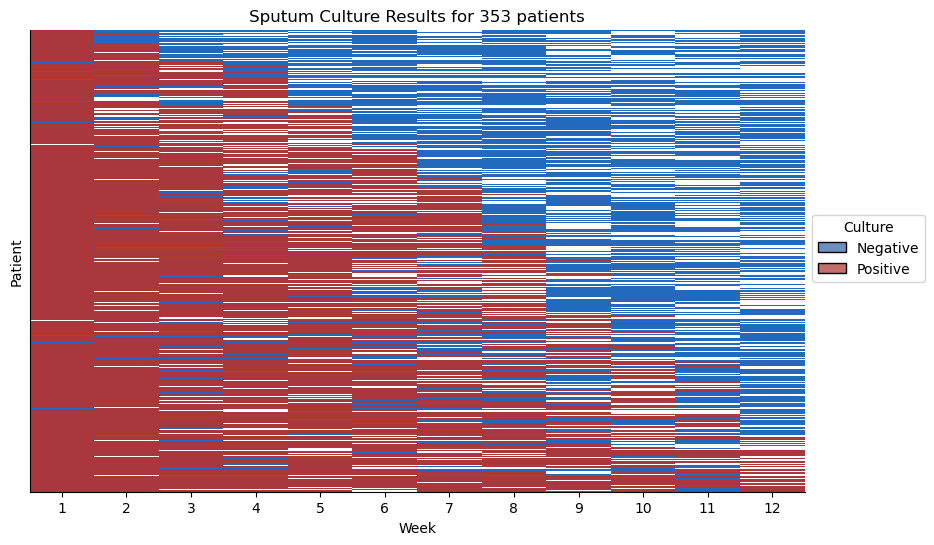

In [9]:
cultures_for_heatmap = df_cultures.query("sample_num <= 12 & pid in @df_TCC_imputed_all.pid").pivot(index='pid', columns='sample_num', values='result')

# same thing done before computing TCC and running imputation
cultures_for_heatmap = cultures_for_heatmap.replace('tb_positive_contaminated', 'tb_positive').replace('tb_negative_contaminated', np.nan).replace('tb_positive', 1).replace('tb_negative', 0)
cultures_for_heatmap.shape

fig, ax = plt.subplots(figsize=(10, 6))

# sort the patients by the number of positive cultures they have, increasing
# sort_lst = pd.DataFrame(cultures_for_heatmap.sum(axis=1)).sort_values(0).index.values

sort_lst = df_TCC_imputed_all.query("pid in @df_trust_patients.pid").sort_values(['TCC'], ascending=[True])['pid'].values

cultures_for_heatmap = cultures_for_heatmap.loc[sort_lst]

sns.heatmap(cultures_for_heatmap, cmap='vlag', cbar=False)

ax.set_yticks([])

plt.ylabel('Patient')
plt.xlabel('Week')

# Create a custom legend
legend_elements = [
    Patch(facecolor=sns.color_palette("vlag").as_hex()[0], edgecolor='black', label='Negative'),
    Patch(facecolor=sns.color_palette("vlag").as_hex()[-1], edgecolor='black', label='Positive')
]

ax.legend(
    handles=legend_elements, 
    title='Culture', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 0.6),  # Adjust the position
    borderaxespad=0
)

plt.title(f"Sputum Culture Results for {cultures_for_heatmap.index.nunique()} patients")
sns.despine()
plt.savefig("figures/sputum_heatmap.svg", bbox_inches='tight')

# Survival Curve, including imputed TCCs

In [18]:
median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_TCC_imputed_all['imp_num'].unique():
    imputed_data = df_TCC_imputed_all.query("imp_num==@imp")

    kmf = lifelines.KaplanMeierFitter()
    kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])
    
    survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))
    
    median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

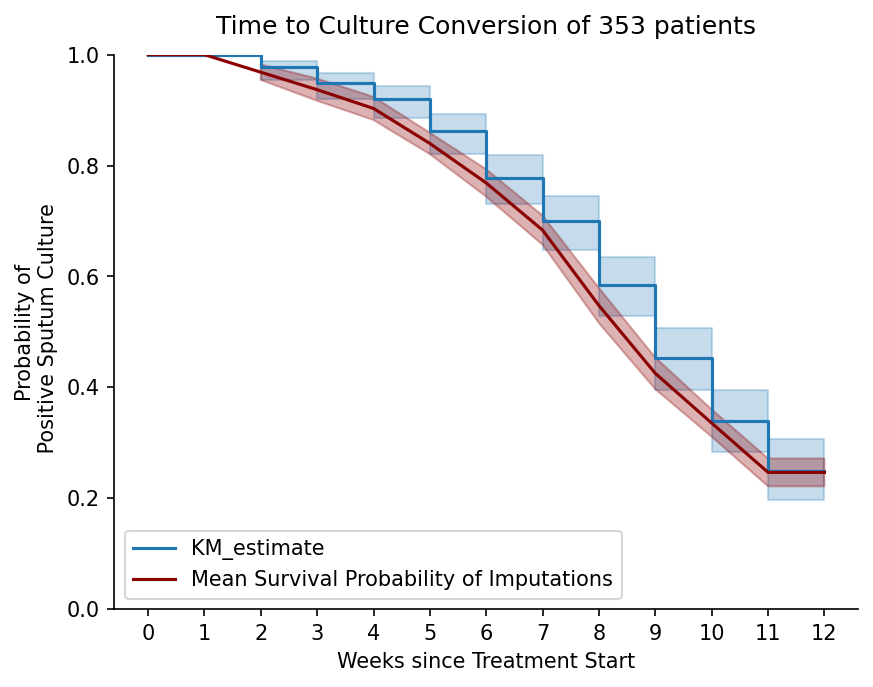

In [21]:
df_TCC = df_TCC.query("pid in @df_TCC_imputed_all.pid")

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC['TCC'], event_observed=df_TCC['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_TCC_imputed_all.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_TCC_imputed_all.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig("./analysis/TRUST/figures/TCC/KM_estimate.svg", bbox_inches='tight')

In [26]:
kmf_full_dataset.event_table[['at_risk', 'censored']].T.to_csv("./analysis/TRUST/figures/TCC/KM_estimate.csv")

In [10]:
median_survival = kmf_full_dataset.median_survival_time_
median_survival

9.0

In [11]:
# probability of being culture-positive at week 12
df_survival.iloc[:, 1:].loc[12].mean()

0.24701471440863854

In [12]:
# fig, ax = plt.subplots(figsize=(12, 10))

# ax = lifelines.plotting.plot_lifetimes(df_TCC['TCC'], event_observed=df_TCC['culture_convert'], ax=ax)

# # ax.vlines(10, 0, 30, lw=1, linestyles='--')
# ax.set_xlabel("weeks")
# ax.set_title("Births and deaths of our population, at $t=12$")

In [26]:
# # 0.78, 0.84
# df_TCC_corrs.rho.mean(), df_TCC_corrs.rho_convert_only.mean()

In [27]:
# df_TCC_imputed_imputation_average = df_TCC_imputed_all.rename(columns={'TCC': 'TCC_imputed', 'culture_convert': 'culture_convert_imputed'}).groupby(["pid"])[['TCC_imputed', 'culture_convert_imputed']].mean().astype(float)#.round().astype(int)

# for col in df_TCC_imputed_imputation_average.columns:
#     df_TCC_imputed_imputation_average[col] = np.round(df_TCC_imputed_imputation_average[col])
    
# # df_TCC_imputed_imputation_average = pd.DataFrame(df_TCC_imputed_all.groupby(["pid"])['TCC_imputed'].mean()).reset_index().merge(pd.DataFrame(df_TCC_imputed_all.groupby(["pid"])['culture_convert_imputed'].agg(pd.Series.mode)).reset_index())

# df_TCC_imputed_imputation_average = df_TCC_imputed_imputation_average.merge(df_TCC, on='pid')

In [28]:
# df_plot = df_TCC_imputed_imputation_average #df_TCC_imputed_plot#.query("~(culture_convert_imputed==1 & culture_convert==1)")

# sns.kdeplot(data=df_plot,
#             x='TCC_imputed',
#             y='TCC',
#             fill=True,
#             #hue='culture_convert'
#            )

# # plt.xlim(df_TCC_imputed_plot.TCC_imputed.min()-1, df_TCC_imputed_plot.TCC_imputed.max()+1)
# # plt.xlim(df_TCC_imputed_plot.TCC.min()-1, df_TCC_imputed_plot.TCC.max()+1)

# plt.title(f"{df_plot.pid.nunique()} patients")
# plt.ylabel("Raw TCC")
# plt.xlabel("Imputed TCC")

# sns.despine()
# plt.show()
# # plt.savefig(f"figures/TCC_imputed.svg", bbox_inches='tight')

In [50]:
cols_lst = [
            'screen_sex',
            'screen_years',
            # 'bmi', # ordinal with 3 string groups
            'bl_bmi', # numerical BMI
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            'HIV_CD4',
            # 'bl_prevtb',
            # 'smear_grade_baseline',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'predicted_PLI',
            # 'predicted_Timika_Score',
            'high_lung_involvement',
            # 'peth_value_baseline',
            # 'bilateral_infiltrates',
            # 'underweight',
            'total_adherence',
            # 'bl_inh_monoresistant',
            # 'inh_resistant',
            # 'adherence_12week',
            # 'alcohol_use',
            # 'bl_mandrax', 
            # 'RIF_AUC',
            # 'INH_AUC',
            # 'EMB_AUC',
            # 'PZA_AUC',
            # 'cxr_finding_chest_radiograph_1', 
            # 'cxr_infiltrate_chest_radiograph_1', 
            # 'cxr_miliary_chest_radiograph_1', 
            # 'cxr_cavity_chest_radiograph_1',
            # 'cxr_lymph_chest_radiograph_1',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cxr_granuloma_chest_radiograph_1',
            'F2',
            'Lineage' # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]

stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'high_lung_involvement', 'HIV_CD4']

non_linear_term_variables = []

In [45]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': 'PLI > 20%',
               'Not_Lineage_2': 'Not Lineage 2',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               'underweight': 'BMI < 18'
             }

# Multivariate Models

## 0. Determine the model formulation by checking the proportional hazards function

In [46]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_TCC_imputed_all,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type='none',
                                                                                                  tb_deaths_only=False,
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 # non_linear_term_variables=nonlinear_variables,
                                                                                                 binary_lineage=True
                                                                                                 )

df_test_results.loc[df_test_results['covariate']=='screen_years', ['HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years'][['HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']]**10

[]
    352 total pids
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


In [47]:
df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

In [48]:
df_violating_covariates.query("p <= 0.05").covariate.value_counts()

covariate
TTP_baseline    6
Name: count, dtype: int64

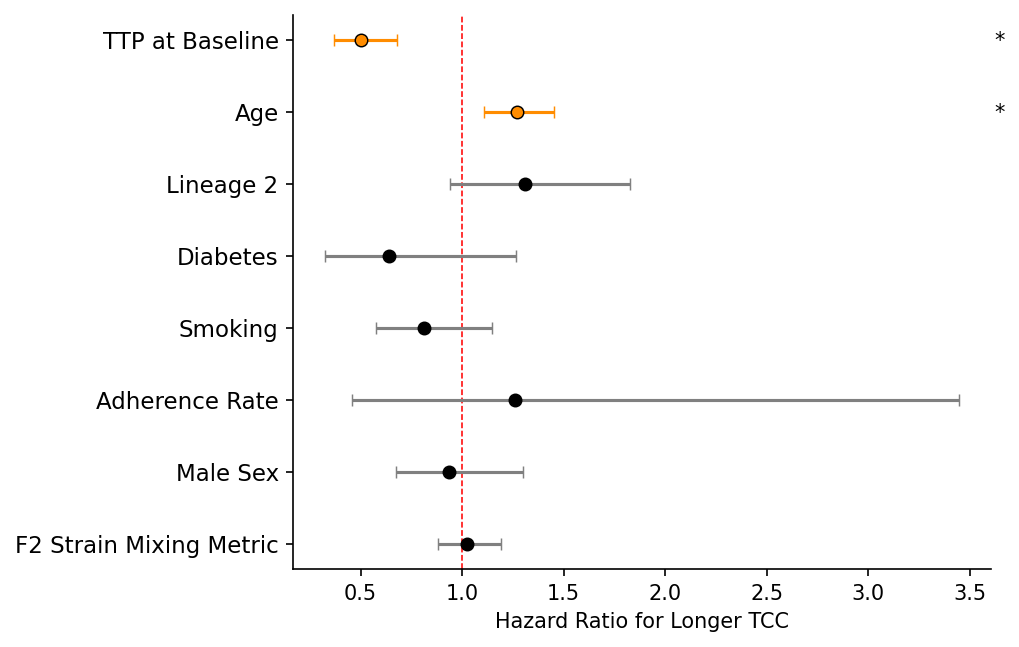

In [49]:
forest_plot(df_test_results,
            df_test_results.sort_values(['pval', 'HR_TCC_assoc'], ascending=[True, False]).covariate.unique(),
            labels_dict,
            val_col='HR_TCC_assoc',
            # saveName="/home/sak0914/MtbQuantCNN/analysis/TRUST/figures/TCC/base_model.svg"
           )

In [43]:
df_test_results.query("covariate=='underweight'")

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,dof_observed,dof_adj,pval,t_critical,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper
8,underweight,-0.211581,0.018403,0.00372,0.022247,0.149153,0.208855,-1.418545,971.534663,0.172771,289.54427,223.06478,0.157427,1.970656,-0.50551,0.082349,1.23563,0.92095,1.657832


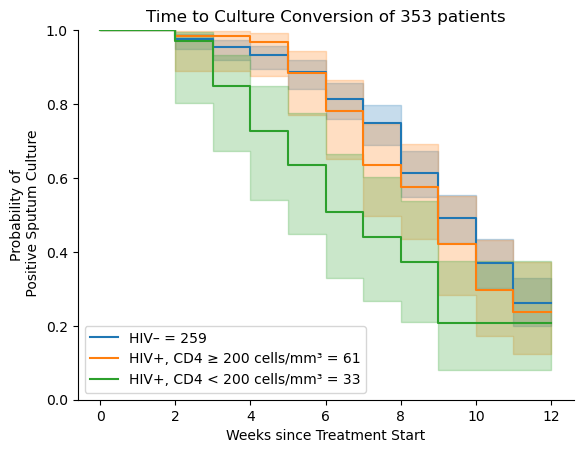

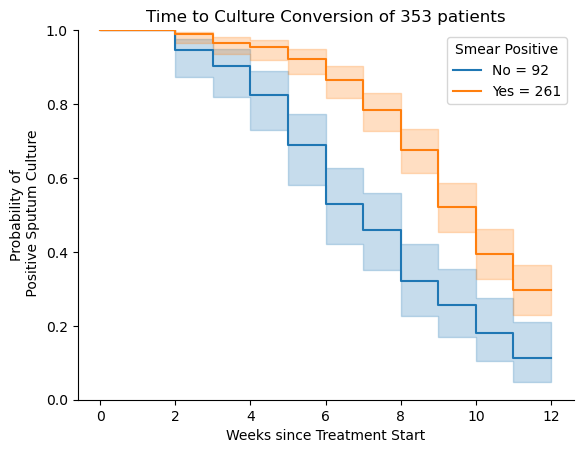

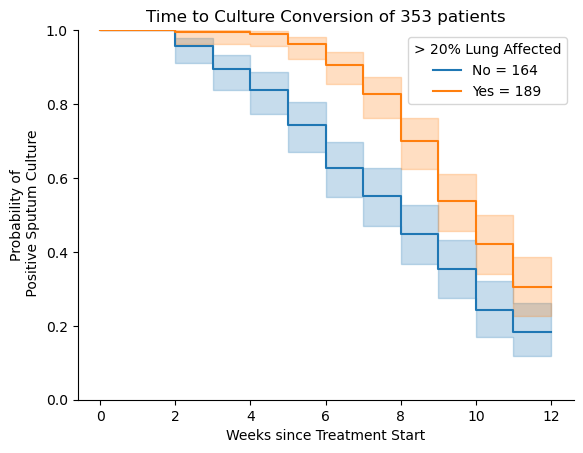

In [20]:
# df_check_stratify_vars = df_trust_patients.query("pid in @df_TCC_imputed_all.pid")
# df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_PLI'] > 20)
# df_check_stratify_vars = df_check_stratify_vars.dropna(subset=cols_lst)
# df_check_stratify_vars['high_lung_involvement'] = df_check_stratify_vars['high_lung_involvement'].astype(int)

# df_check_stratify_vars.loc[df_check_stratify_vars['Lineage'].str.contains('2'), 'L2'] = 1
# df_check_stratify_vars.loc[~df_check_stratify_vars['Lineage'].str.contains('2'), 'L2'] = 0
# df_check_stratify_vars['L2'] = df_check_stratify_vars['L2'].astype(int)

# categorical_cols = ['screen_sex', 'fstrom1_baseline', 'HIV_CD4', 'smear_pos_no_contam_sputum_specimen_1', 'diabetes', 'high_lung_involvement', 'L2']
# labels_lst = ['Male Sex', 'Smoking', 'HIV_CD4', 'Smear Positive', 'Diabetes', '> 20% Lung Affected', 'Lineage 2']
# legend_name_dict = dict(zip(categorical_cols, labels_lst))

# df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval']).set_index('covariate')

# for variable in categorical_cols:
    
#     fig, ax = plt.subplots()
    
#     df_check_stratify_vars[variable] = df_check_stratify_vars[variable].astype(int)
    
#     if variable == 'HIV_CD4':
#         legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
#         color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
#     # elif variable == 'Lineage 2':
#     #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
#     #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
#     else:
#         legend_marker_dict = {0: 'No', 1: 'Yes'}
#         color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

#     # sort so that 0 is plotted before 1
#     for group in np.sort(df_check_stratify_vars[variable].unique()):
        
#         df_single_group = df_check_stratify_vars.query(f"{variable}==@group")
            
#         kmf = lifelines.KaplanMeierFitter()
#         kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
            
#         kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

#         if variable != 'HIV_CD4':
#             plt.legend(title=legend_name_dict[variable])

#     # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
#     if variable == 'HIV_CD4':
        
#         # do them separately for each of the two HIV groups relative to the no HIV group
#         logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_check_stratify_vars.query(f"{variable}==1")['TCC'], 
#                                                                   durations_B=df_check_stratify_vars.query(f"{variable}==0")['TCC'], 
#                                                                   event_observed_A=df_check_stratify_vars.query(f"{variable}==1")['culture_convert'], 
#                                                                   event_observed_B=df_check_stratify_vars.query(f"{variable}==0")['culture_convert'],
#                                                                  p = 0,
#                                                                  q = 0,
#                                                                  )
        
#         df_logrank_pvalues.loc['HIV_High_CD4', :] = logRank_test_results.p_value
        
#         logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_check_stratify_vars.query(f"{variable}==2")['TCC'], 
#                                                                   durations_B=df_check_stratify_vars.query(f"{variable}==0")['TCC'], 
#                                                                   event_observed_A=df_check_stratify_vars.query(f"{variable}==2")['culture_convert'], 
#                                                                   event_observed_B=df_check_stratify_vars.query(f"{variable}==0")['culture_convert'],
#                                                                  p = 0,
#                                                                  q = 0,
#                                                                  )
        
#         df_logrank_pvalues.loc['HIV_Low_CD4', :] = logRank_test_results.p_value
        
#     else:
#         logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_check_stratify_vars.query(f"{variable}==1")['TCC'], 
#                                                                   durations_B=df_check_stratify_vars.query(f"{variable}==0")['TCC'], 
#                                                                   event_observed_A=df_check_stratify_vars.query(f"{variable}==1")['culture_convert'], 
#                                                                   event_observed_B=df_check_stratify_vars.query(f"{variable}==0")['culture_convert'],
#                                                                  p = 0,
#                                                                  q = 0,
#                                                                  )

#     # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
#     plt.ylim(0, 1)

#     sns.despine()
#     plt.title(f"Time to Culture Conversion of {df_check_stratify_vars.pid.nunique()} patients")
#     plt.ylabel("Probability of\n Positive Sputum Culture") #
#     plt.xlabel("Weeks since Treatment Start")
#     sns.despine()
    
#     if variable != 'HIV_CD4':
#         df_logrank_pvalues.loc[variable, :] = logRank_test_results.p_value
    
#     if variable in stratify_covariates:
#         plt.savefig(f"figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
#     else:
#         plt.close()
    
# df_logrank_pvalues.to_csv("./model_results/TCC/KM_logRank_test_pvalues.csv")

In [29]:
df_logrank_pvalues = pd.read_csv("./model_results/TCC/KM_logRank_test_pvalues.csv")

In [30]:
df_logrank_pvalues.sort_values("pval")

,covariate,pval
4,smear_pos_no_contam_sputum_specimen_1,1.830358e-09
6,high_lung_involvement,1.715884e-06
3,HIV_Low_CD4,3.938424e-04
7,L2,1.303470e-02
0,screen_sex,7.405684e-02
2,HIV_High_CD4,3.866382e-01
5,diabetes,3.886864e-01
1,fstrom1_baseline,8.606925e-01


In [65]:
# df_TCC_imputed_all['median_survival'] = df_TCC_imputed_all['imp_num'].map(median_survival_imputations)

# # for consistency with effect direction. This is not the same as culture_convert because that includes some censoring
# df_TCC_imputed_all.loc[df_TCC_imputed_all['TCC'] == 12, 'culture_positive_at_12weeks'] = 1
# df_TCC_imputed_all['culture_positive_at_12weeks'] = df_TCC_imputed_all['culture_positive_at_12weeks'].fillna(0).astype(int)

# # culture positivity at the median
# df_TCC_imputed_all.loc[df_TCC_imputed_all['TCC'] > df_TCC_imputed_all['median_survival'], 'culture_positive_at_median'] = 1
# df_TCC_imputed_all['culture_positive_at_median'] = df_TCC_imputed_all['culture_positive_at_median'].fillna(0).astype(int)

In [66]:
# df_pool_median = compute_relative_risks_rubins_rules(df_trust_patients, df_TCC_imputed_all, cols_lst, 'culture_positive_at_median')

In [67]:
# df_pool_12weeks = compute_relative_risks_rubins_rules(df_trust_patients, df_TCC_imputed_all, cols_lst, 'culture_positive_at_12weeks')

In [23]:
# df_pool_median.query("covariate in ['smear_pos_no_contam_sputum_specimen_1', 'HIV_High_CD4', 'HIV_Low_CD4', 'high_lung_involvement']")[['covariate', 'pval', 'HR_TCC_assoc']]

In [24]:
# df_pool_12weeks.query("covariate in ['smear_pos_no_contam_sputum_specimen_1', 'HIV_High_CD4', 'HIV_Low_CD4', 'high_lung_involvement']")[['covariate', 'pval', 'HR_TCC_assoc']]

In [25]:
# # the columns say HR but it's actually RR
# df_stratify_variables_relative_risks = pd.DataFrame(columns = ['covariate', 'HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper', 'pval']).set_index('covariate')

# for variable in ['smear_pos_no_contam_sputum_specimen_1', 'high_lung_involvement', 'HIV_High_CD4', 'HIV_Low_CD4']:

#     # compute relative risk. For HIV/CD4, it's done low CD4 count vs. the others
#     log_RRs_single_variable, stderrs_log_RR_single_variable = compute_relative_risk_with_confidence_interval_on_imputations(df_trust_patients, df_TCC_imputed_all, variable)

#     lb, ub, RR, pval = rubins_rules_relative_risk(log_RRs_single_variable, stderrs_log_RR_single_variable)
#     df_stratify_variables_relative_risks.loc[variable, :] = [RR, lb, ub, pval]

# df_stratify_variables_relative_risks.to_csv("./model_results/TCC/relative_risk_stratify_variables.csv")
# df_stratify_variables_relative_risks = pd.read_csv("./model_results/TCC/relative_risk_stratify_variables.csv")

## 2. Add MICs individually to the model

In [18]:
exclude_resistance_lst = [0]
MIC_type_lst = ['predicted', 'measured']

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, drugs_lst))
# param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, drugs_lst + [drugs_lst] + [['RIF', 'INH', 'EMB']]))
# param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, drugs_lst + [drugs_lst]))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, drug in param_grid
]

len(param_grid_dicts)

8

In [83]:
df_TCC_model_final = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

#     # skip cases where MIC = measured and PZA is included because it drops the sample size
#     if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
#         print("    Skipping model")
        
#     else:
    # only include drug AUCs if the MIC is included
    drug_AUC_lst = [f"{drug}_AUC" for drug in params_lst['include_drugs_lst']]
    print(f"    {params_lst['include_drugs_lst']}, {drug_AUC_lst}")
    
    if 'RIF' in params_lst['include_drugs_lst'] and params_lst['MIC_type'] == 'predicted':
        binarize_drugs = ['RIF']
        log_transform_drugs = list(set(params_lst['include_drugs_lst']) - set(['RIF']))
    else:
        binarize_drugs = []
        log_transform_drugs = params_lst['include_drugs_lst']

    df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                      df_pred_combined,
                                                                                                       TRUST_phenos,
                                                                                                      df_TCC_imputed_all,
                                                                                                      cols_lst + drug_AUC_lst,
                                                                                                      event_col = 'culture_convert',
                                                                                                      time_col = 'TCC',
                                                                                                      exclude_resistance=params_lst['exclude_resistance'],
                                                                                                      MIC_type=params_lst['MIC_type'],
                                                                                                      tb_deaths_only=False,
                                                                                                      include_drugs=params_lst['include_drugs_lst'],
                                                                                                     binarize_drugs = binarize_drugs,
                                                                                                     log_transform_drugs=log_transform_drugs,
                                                                                                      invert_OR=True,
                                                                                                      stratify_variables=stratify_covariates,
                                                                                                     binary_lineage=True
                                                                                 )

    for model_idx in range(len(cph_models_imputations)):

        df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], 
                                                                                df_samples_imputations[model_idx], 
                                                                                time_transform='rank').summary.reset_index().rename(columns={'index': 'covariate'})

        violating_covariates = df_proportional_hazards.query("p <= 0.01").covariate.values

        if len(violating_covariates) > 0:
            print(f"Predictors {violating_covariates} violated the proportional hazards assumptions")

    df_test_results['exclude_resistance'] = params_lst['exclude_resistance']
    df_test_results['MIC_type'] = params_lst['MIC_type']
    df_test_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
    df_test_results['num_pids'] = df_samples_imputations[0]['pid'].nunique()

    df_TCC_model_final.append(df_test_results)

df_TCC_model_final = pd.concat(df_TCC_model_final)

# annotate significance
df_TCC_model_final.loc[(df_TCC_model_final["pval"] <= 0.05), 'significant'] = 1
df_TCC_model_final.to_csv("~/MtbQuantCNN/analysis/TRUST/model_results/TCC/3var_stratified.csv", index=False)

Model 1
    ['RIF'], ['RIF_AUC']
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
    353 total pids
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.1% are high
[]
Binarized RIF_pred

In [7]:
df_TCC_model_final = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/model_results/TCC/3var_stratified.csv")
print(df_TCC_model_final.query("significant==1").covariate.unique())

OR_col = 'HR_TCC_assoc'

# transform some hazard ratios for interpretability
# 1. Age: make it for each decade
# 2. RIF AUC: by 10. It ranges from 0 - 120, but mostly 0-70. Nah, the confidence interval looks weird.
# 3: % lung involvement: by 10 also. Ranges from 0-80. Nah, makes it huge. Stick to 1%

for col in ['screen_years']:# + list(df_TCC_model_final.query("covariate.str.endswith('_AUC')").covariate.unique()):#, 'RIF_AUC']:

    df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# MIC HRs should be transformed to per 0.01 µg/mL for RIF, INH, and EMB and per 10 µg/mL for PZA  
# transform the confidence intervals for the predicted MICs to per 0.01, as they did in the NEJM paper
for col in df_TCC_model_final.query("covariate.str.endswith('_midpoint') | covariate.str.endswith('_pred_MIC')").covariate.unique():

    multiply_factor = 0.1
        
    print(col, multiply_factor)
    
    df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**multiply_factor

['TTP_baseline' 'screen_years']
INH_pred_MIC 0.1
EMB_pred_MIC 0.1
PZA_pred_MIC 0.1
RIF_midpoint 0.1
INH_midpoint 0.1
EMB_midpoint 0.1
PZA_midpoint 0.1


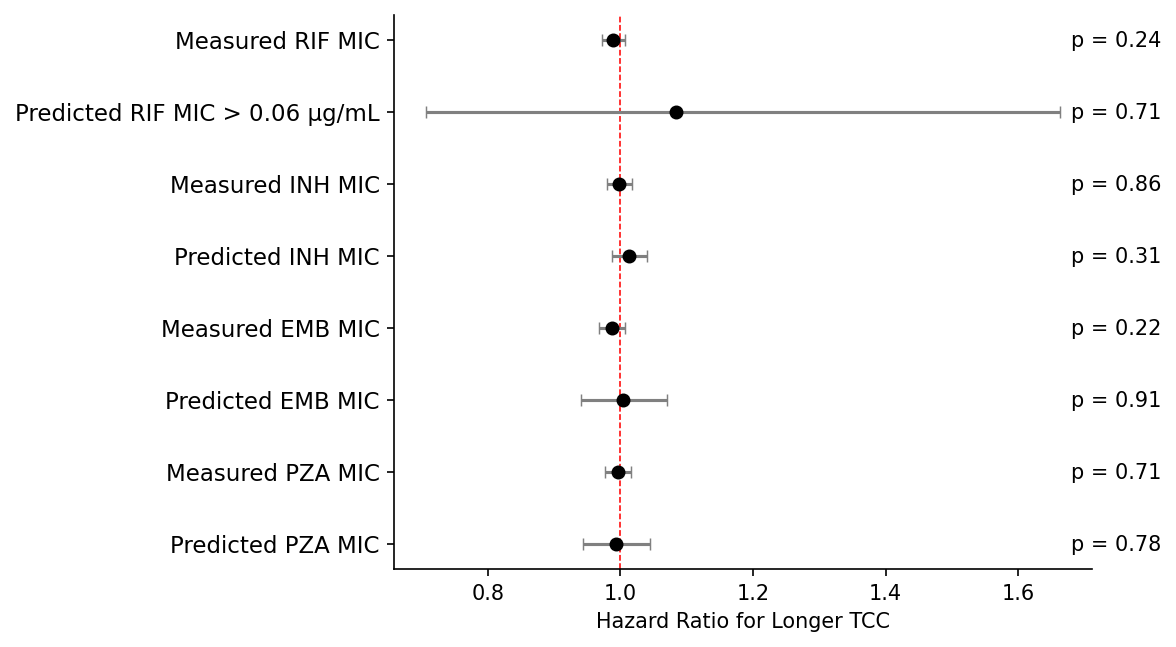

In [89]:
# drug_covariates = ['RIF_midpoint', 'RIF_pred_MIC', 'RIF_AUC', 'INH_midpoint', 'INH_pred_MIC', 'INH_AUC', 'EMB_midpoint', 'EMB_pred_MIC', 'EMB_AUC', 'PZA_midpoint', 'PZA_pred_MIC', 'PZA_AUC']
drug_covariates = ['RIF_midpoint', 'RIF_pred_MIC_high', 'INH_midpoint', 'INH_pred_MIC', 'EMB_midpoint', 'EMB_pred_MIC', 'PZA_midpoint', 'PZA_pred_MIC']

forest_plot(df_TCC_model_final.query("include_drugs in ['RIF', 'INH', 'EMB', 'PZA']").query("covariate in @drug_covariates"),
            drug_covariates,
            labels_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            log=False,
            pval_offset=1.01,
            # saveName="./analysis/TRUST/figures/TCC/forest_plot_not_significant.svg"
           )

In [120]:
drug_covariates = ['RIF_midpoint', 'RIF_pred_MIC_high', 'RIF_pred_MIC', 'RIF_AUC', 'INH_midpoint', 'INH_pred_MIC', 'INH_AUC', 'EMB_midpoint', 'EMB_pred_MIC', 'EMB_AUC', 'PZA_midpoint', 'PZA_pred_MIC', 'PZA_AUC']

microbiological_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'TTP_baseline', 'high_lung_involvement', 'Lineage_2', 'F2']

demographic_covariates = ['screen_sex', 'screen_years', 'bl_bmi', 'HIV_High_CD4', 'HIV_Low_CD4', 'diabetes', 'fstrom1_baseline']

covariate_groups_lst = [drug_covariates, microbiological_covariates, demographic_covariates]

figure_names = ['forest_plot_predicted_MIC', 'forest_plot_microbiological', 'forest_plot_demographics']

In [121]:
for i, group in enumerate(covariate_groups_lst):
    
    forest_plot(df_TCC_model_final.query("MIC_type=='predicted' & include_drugs=='RIF,INH,EMB,PZA'"), 
                group, 
                labels_dict, 
                val_col='HR_TCC_assoc', 
                alpha=0.05, 
                pval_offset=1.05,
                df_stratify_variables_results=df_logrank_pvalues.query("covariate in ['HIV_High_CD4', 'HIV_Low_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1']"),
                saveName=f"./figures/TCC/{figure_names[i]}.svg",
               )
    
forest_plot(df_TCC_model_final.query("MIC_type=='measured' & include_drugs=='RIF,INH,EMB'"), 
            drug_covariates, 
            labels_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            pval_offset=1.05,
            df_stratify_variables_results=df_logrank_pvalues.query("covariate in ['HIV_High_CD4', 'HIV_Low_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1']"),
            saveName="./figures/TCC/forest_plot_measured_MIC.svg"
           )

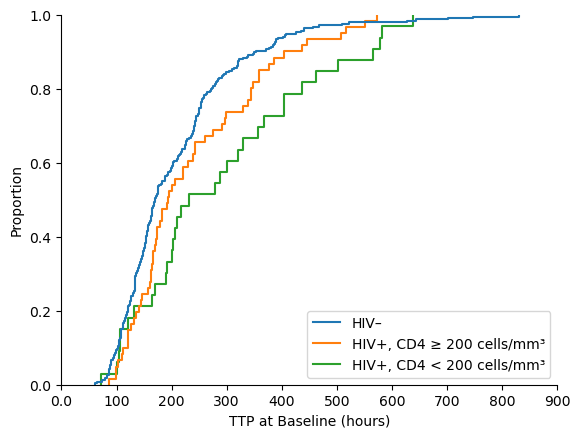

In [119]:
df_TTP_plot = df_trust_patients.copy()

label_map = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}

df_TTP_plot['HIV_CD4'] = df_TTP_plot['HIV_CD4'].map(label_map)

fig, ax = plt.subplots()

sns.ecdfplot(data=df_TTP_plot,
             x='TTP_baseline',
             # log_scale=10,
             hue='HIV_CD4',
             palette='tab10',
             legend=True,
             ax=ax
            )

def format_sigfig_fixed(x, sig=2):
    if x == 0:
        return 0.00
    elif x < 0.01:
        # return these in scientific notation because they are so small
        return "{:.1e}".format(x)
    elif x < 0.1:
        return np.round(x, 2)
    else:
        # Determine how many decimal places to show
        digits = sig - int(np.floor(np.log10(abs(x)))) - 1
        if digits < 0:
            # Round to nearest 10s, 100s, etc.
            rounded = round(x, digits)
            return f"{rounded:.0f}"
        else:
            return f"{x:.{digits}f}"


# Get the current legend and set the title to None
legend = plt.gca().get_legend()

if legend is not None:
    legend.set_title(None)
    
ax.set_xticks(ax.get_xticks(), [format_sigfig_fixed(label) for label in ax.get_xticks()])

# plt.xlim(df_TTP_plot['TTP_baseline'].min()-10, df_TTP_plot['TTP_baseline'].max()+10)

plt.xlabel('TTP at Baseline (hours)')
    
sns.despine()
plt.savefig("./figures/TCC/TTP_HIV_CD4_ECDF.svg", bbox_inches='tight')

In [111]:
df_TTP_plot.groupby('HIV_CD4')['smear_grade_baseline'].mean()

HIV_CD4
HIV+, CD4 < 200 cells/mm³    1.264706
HIV+, CD4 ≥ 200 cells/mm³    1.590164
HIV–                         1.794677
Name: smear_grade_baseline, dtype: float64

In [107]:
st.ttest_ind(np.log(df_trust_patients.query("HIV_CD4==0")['TTP_baseline'].dropna()),
             np.log(df_trust_patients.query("HIV_CD4==1")['TTP_baseline'].dropna()),
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-2.1255392869899197, pvalue=0.0181331224766192, df=90.47802747509745)

In [109]:
st.ttest_ind(df_trust_patients.query("HIV_CD4==1")['TTP_baseline'].dropna(),
             df_trust_patients.query("HIV_CD4==2")['TTP_baseline'].dropna(),
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-1.5591322607574685, pvalue=0.06249127521800993, df=52.4205915072182)

# Post Model-Fitting Analyses

In [162]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_TCC_imputed_all,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                  MIC_type='predicted',
                                                                                                  include_drugs=drugs_lst,
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                             )

    348 total pids



KeyboardInterrupt



In [21]:
df_plot = combine_survival_probabilities_across_imputations(df_samples_imputations, cph_models_imputations, stratify_covariates)

8 unique condition combinations


In [22]:
def trapezoidal_rule(df_single_group):

    df_single_group = df_single_group.sort_values("Week").reset_index(drop=True)
    
    h = df_single_group['Week'].max() / len(df_single_group)

    total_area = 0

    for i, row in df_single_group.iterrows():

        if i > 0:
            # survival probabilities must be monotonically decreasing
            assert row['Mean'] <= df_single_group['Mean'].values[i-1]
            total_area += 0.5 * h * (row['Mean'] + df_single_group['Mean'].values[i-1])

    return total_area

In [23]:
def plot_baseline_survival_curve(df_plot, select_params=None, plot_ci=False, saveName=None):

    if select_params is not None:
        df_plot = df_plot.query("variable in @select_params")

    df_trapezoidal_areas = pd.DataFrame(columns = ['group', 'area'])
    i = 0
    
    for group in df_plot['variable'].unique():
    
        df_trapezoidal_areas.loc[i, :] = [group, trapezoidal_rule(df_plot.loc[df_plot['variable']==group])]
        i += 1

    # plot in order of decreasing TCC for ease of matching colors in the legend order
    plot_order = df_trapezoidal_areas.sort_values("area", ascending=False)['group'].values

    # plot in order of decreasing TCC for ease of matching colors in the legend order
    # plot_order = df_plot.groupby('variable')['Mean'].median().sort_values(ascending=False).index.values

    fig, ax = plt.subplots()
    
    # plot the mean survival probability at each week across the imputations
    sns.lineplot(data=df_plot,
                 x='Week',
                 y='Mean',
                 hue='variable',
                 hue_order=plot_order,
                 # palette='colorblind'
                )

    colors = sns.color_palette("tab10").as_hex()
    
    plt.title("Survival Probabilities across Stratified Groups")
    plt.ylabel('Proportion Sputum Positive')

    if plot_ci:

        # Calculate and plot the confidence interval using 1.96 * std for ~95% CI
        df_plot['CI_lower'] = df_plot['Mean'] - 1.96 * df_plot['SD']
        df_plot['CI_upper'] = df_plot['Mean'] + 1.96 * df_plot['SD']
        
        for i, group in enumerate(plot_order):
            df_plot_single_group = df_plot.query("variable==@group").sort_values("Week")
            plt.fill_between(df_plot_single_group.Week, df_plot_single_group['CI_lower'], df_plot_single_group['CI_upper'], alpha=0.3, color=colors[i])

    # Set x-axis ticks to show all integers
    ax.set_xticks(range(0, int(df_plot.Week.max()) + 1))
    plt.ylim(0, 1)
    
    ax.legend(loc='upper center', bbox_to_anchor=(1.25, 1.1), fontsize=10)
    
    sns.despine()

    if saveName is not None:
        plt.savefig(saveName, bbox_inches='tight')
        # plt.close()
    else:
        plt.show()

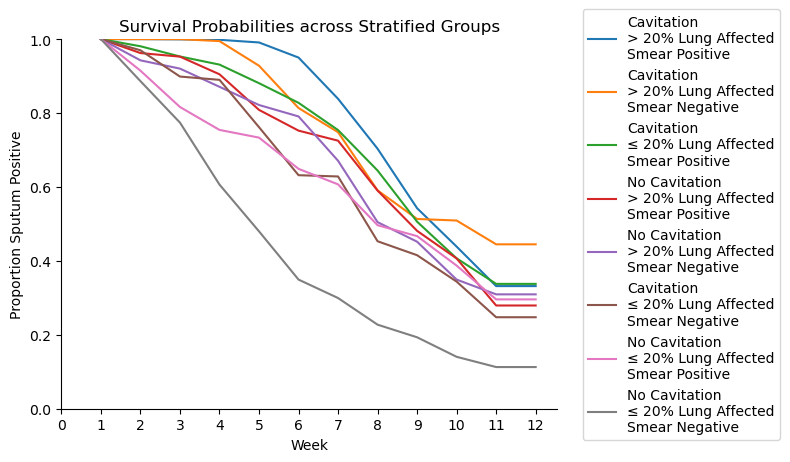

In [24]:
plot_baseline_survival_curve(df_plot, saveName="./figures/TCC_predicted_MIC_stratified_survival_curves.svg")

In [39]:
# select_params = ['No Cavitation\n≤ 20% Lung Affected\nSmear Negative', # all 0s
#                  'No Cavitation\n≤ 20% Lung Affected\nSmear Positive', # low lung involvement = 1 only, expect best outcomes
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_smear_comparison_low_lung_involvement.svg"
#                             )

In [40]:
# select_params = ['No Cavitation\n> 20% Lung Affected\nSmear Negative', # all 0s
#                  'No Cavitation\n> 20% Lung Affected\nSmear Positive', # low lung involvement = 1 only, expect best outcomes,
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_smear_comparison_high_lung_involvement.svg"
#                             )

In [41]:
# select_params = ['No Cavitation\n≤ 20% Lung Affected\nSmear Negative', # all 0s
#                  'Cavitation\n≤ 20% Lung Affected\nSmear Negative', # low lung involvement = 1 only, expect best outcomes,
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_cavitation_comparison_low_lung_involvement.svg"
#                             )

In [42]:
# select_params = ['No Cavitation\n> 20% Lung Affected\nSmear Negative', # all 0s
#                  'Cavitation\n> 20% Lung Affected\nSmear Negative', # low lung involvement = 1 only, expect best outcomes,
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_cavitation_comparison_high_lung_involvement.svg"
#                             )

In [43]:
# # cavitation + smear positive + ≤ 20% lung vs. no cavitation + smear negative + > 20% lung
# select_params = [
#                 # 'No Cavitation\n> 20% Lung Affected\nSmear Negative',
#                  'Cavitation\n≤ 20% Lung Affected\nSmear Positive',
#                  'No Cavitation\n> 20% Lung Affected\nSmear Negative'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              # saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_cavitation_comparison_high_lung_involvement.svg"
#                             )

# Binarize the MICs at the CCs to see if that significantly worsens model fit relative to using MICs

Other drugs have little to no resistance, so difficult to interpret

In [106]:
TRUST_phenos.query("pid in @final_keep_pids")[['INH_upper_bound', 'EMB_upper_bound', 'RIF_upper_bound']].max()

INH_upper_bound    inf
EMB_upper_bound    inf
RIF_upper_bound    0.5
dtype: float64

In [107]:
df_pred_combined.query("pid in @final_keep_pids")[['RIF_pred_MIC', 'INH_pred_MIC', 'EMB_pred_MIC', 'PZA_pred_MIC']].max()

RIF_pred_MIC     0.064936
INH_pred_MIC     4.311705
EMB_pred_MIC     8.729896
PZA_pred_MIC    35.918034
dtype: float64

In [36]:
def compare_binary_continuous_resistance_models(drug, final_patient_predictors, MIC_type, include_no_MIC_model=True):

    # must be testing MICs in this function
    assert MIC_type in ['predicted', 'measured']

    # model with binary resistance
    _, _, cph_models_imputation_binary = fit_cox_models_all_imputations(df_trust_patients,
                                                                          df_pred_combined,
                                                                           TRUST_phenos,
                                                                           df_imputed,
                                                                          df_TCC_imputed_all,
                                                                          final_patient_predictors,
                                                                          event_col = 'culture_convert',
                                                                          time_col = 'TCC',
                                                                          exclude_resistance=0,
                                                                          MIC_type=MIC_type,
                                                                          binarize_MICs=True,
                                                                          tb_deaths_only=False,
                                                                          include_drugs=[drug],
                                                                          invert_OR=True,
                                                                          include_interactions=False,
                                                                          penalize_model=False,
                                                                          original_dataset_only=False,
                                                                          stratify_variables=stratify_covariates,
                                                                         )

    # model with MIC
    _, _, cph_models_imputation = fit_cox_models_all_imputations(df_trust_patients,
                                                                  df_pred_combined,
                                                                   TRUST_phenos,
                                                                   df_imputed,
                                                                  df_TCC_imputed_all,
                                                                  final_patient_predictors,
                                                                  event_col = 'culture_convert',
                                                                  time_col = 'TCC',
                                                                  exclude_resistance=0,
                                                                  MIC_type=MIC_type,
                                                                  binarize_MICs=False,
                                                                  tb_deaths_only=False,
                                                                  include_drugs=[drug],
                                                                  invert_OR=True,
                                                                  include_interactions=False,
                                                                  penalize_model=False,
                                                                  original_dataset_only=False,
                                                                  stratify_variables=stratify_covariates,
                                                                 )

    # model without resistance
    if include_no_MIC_model:
        _, _, cph_models_imputation_no_resistance = fit_cox_models_all_imputations(df_trust_patients,
                                                                              df_pred_combined,
                                                                               TRUST_phenos,
                                                                               df_imputed,
                                                                              df_TCC_imputed_all,
                                                                              final_patient_predictors,
                                                                              event_col = 'culture_convert',
                                                                              time_col = 'TCC',
                                                                              exclude_resistance=0,
                                                                              MIC_type='none',
                                                                              binarize_MICs=False,
                                                                              tb_deaths_only=False,
                                                                              include_drugs=[drug],
                                                                              invert_OR=True,
                                                                              include_interactions=False,
                                                                              penalize_model=False,
                                                                              original_dataset_only=False,
                                                                              stratify_variables=stratify_covariates,
                                                                              # cluster_col='household_num'
                                                                             )

        return cph_models_imputation_no_resistance, cph_models_imputation, cph_models_imputation_binary

    else:
        return cph_models_imputation, cph_models_imputation_binary

In [37]:
cph_models_imputation_no_resistance, cph_models_imputation_INH_meas, cph_models_imputation_INH_meas_binary = compare_binary_continuous_resistance_models('INH', final_patient_predictors, 'measured', include_no_MIC_model=True)

    361 total pids
    361 total pids
    362 total pids


In [38]:
cph_models_imputation_INH_pred, cph_models_imputation_INH_pred_binary = compare_binary_continuous_resistance_models('INH', final_patient_predictors, 'predicted', include_no_MIC_model=False)

    362 total pids
    362 total pids


In [58]:
# not worth doing an LRT because if the variables were not significantly associated with TCC, then they would not be significant in an LRT 
# log_like_no_MIC = [cph.log_likelihood_ for cph in cph_models_imputation_no_resistance]
AIC_no_INH = [cph.AIC_partial_ for cph in cph_models_imputation_no_resistance]

# smaller AIC means better model
AIC_meas_INH = [cph.AIC_partial_ for cph in cph_models_imputation_INH_meas]
AIC_meas_INH_binary = [cph.AIC_partial_ for cph in cph_models_imputation_INH_meas_binary]

# smaller AIC means better model
AIC_pred_INH = [cph.AIC_partial_ for cph in cph_models_imputation_INH_pred]
AIC_pred_INH_binary = [cph.AIC_partial_ for cph in cph_models_imputation_INH_pred_binary]

In [60]:
pd.DataFrame({'imp': np.arange(len(AIC_meas_INH)) + 1,
              'AIC_no_INH_MIC': AIC_no_INH,
              'AIC_measured_INH_MIC': AIC_meas_INH,
              'AIC_measured_INH_binary': AIC_meas_INH_binary,
              'AIC_predicted_INH_MIC': AIC_pred_INH,
              'AIC_predicted_INH_binary': AIC_pred_INH_binary,
             }).to_csv("TCC_INH_AIC_comparison.csv", index=False)

In [61]:
# using INH midpoint has lower AIC than INH binary resistance determined from measured MIC, whoo
st.ttest_rel(AIC_meas_INH, AIC_meas_INH_binary, alternative='less')

TtestResult(statistic=-2.7387111330325316, pvalue=0.005217460365262771, df=29)

In [64]:
# is measured INH MIC better than no INH MIC? Yes
np.mean(np.array(AIC_meas_INH) - np.array(AIC_no_INH))

-5.584892114385972

In [68]:
# using predicted INH MIC worsens the model fit over no INH MIC
st.ttest_rel(AIC_pred_INH, AIC_no_INH, alternative='greater')

TtestResult(statistic=5.440012578387816, pvalue=3.7358006054281686e-06, df=29)

In [62]:
# using predicted INH MIC vs. binary resistance determined from predicted INH MIC is no different
st.ttest_rel(AIC_pred_INH, AIC_pred_INH_binary, alternative='two-sided')

TtestResult(statistic=0.17074610461060044, pvalue=0.8656091480055009, df=29)

# Is Binary INH Resistance associated with TCC?

In [53]:
exclude_resistance_lst = [0]
MIC_type_lst = ['predicted', 'measured']

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, ['INH']))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, drug in param_grid
]

len(param_grid_dicts)

2

In [55]:
df_TCC_model_binary_R = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

    # skip cases where MIC = measured and PZA is included because it drops the sample size
    if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
        print("    Skipping model")
    else:
        df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                          df_pred_combined,
                                                                                                           TRUST_phenos,
                                                                                                           df_imputed,
                                                                                                          df_TCC_imputed_all,
                                                                                                          final_patient_predictors,
                                                                                                          event_col = 'culture_convert',
                                                                                                          time_col = 'TCC',
                                                                                                          exclude_resistance=params_lst['exclude_resistance'],
                                                                                                          MIC_type=params_lst['MIC_type'],
                                                                                                          binarize_MICs=True,
                                                                                                          tb_deaths_only=False,
                                                                                                          include_drugs=params_lst['include_drugs_lst'],
                                                                                                          invert_OR=True,
                                                                                                          include_interactions=False,
                                                                                                          penalize_model=False,
                                                                                                          original_dataset_only=False,
                                                                                                          stratify_variables=stratify_covariates,
                                                                                     )

        for model_idx in range(len(cph_models_imputations)):

            df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], 
                                                                                    df_samples_imputations[model_idx], 
                                                                                    time_transform='rank').summary.reset_index().rename(columns={'index': 'covariate'})
        
            # diabetes has a p-value of like 0.0105
            violating_covariates = df_proportional_hazards.query("p <= 0.01").covariate.values

            if len(violating_covariates) > 0:
                print(f"Predictors {violating_covariates} violated the proportional hazards assumptions")
                
        df_test_results['exclude_resistance'] = params_lst['exclude_resistance']
        df_test_results['MIC_type'] = params_lst['MIC_type']
        df_test_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
        df_test_results['num_pids'] = df_samples_imputations[0]['pid'].nunique()
            
        df_TCC_model_binary_R.append(df_test_results)

df_TCC_model_binary_R = pd.concat(df_TCC_model_binary_R)

# annotate significance
df_TCC_model_binary_R.loc[(df_TCC_model_binary_R["pval"] <= 0.05), 'significant'] = 1
df_TCC_model_binary_R.to_csv("./model_results/TCC_with_stratification_binary_R.csv", index=False)

Model 1
    362 total pids
Model 2
    361 total pids


In [57]:
df_TCC_model_binary_R.query("pval <= 0.05")

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,...,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper,exclude_resistance,MIC_type,include_drugs,num_pids,significant
4,screen_years,-0.021987,0.000029,0.000014,0.000044,0.006607,0.501711,-3.327884,259.814354,0.334093,...,-0.034998,-0.008977,1.022231,1.009018,1.035617,0,predicted,INH,362,1.0
3,RIF_AUC,0.020649,0.000081,0.000020,0.000102,0.010101,0.260639,2.044178,678.421772,0.206752,...,0.000815,0.040482,0.979563,0.960327,0.999185,0,measured,INH,361,1.0
4,screen_years,-0.022517,0.000029,0.000014,0.000044,0.006631,0.504388,-3.395898,257.981593,0.335278,...,-0.035574,-0.009460,1.022772,1.009505,1.036214,0,measured,INH,361,1.0
